In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re as r

In [4]:
path = r'C:\Users\ACER\Documents\datathon-2026-round-1\Datathon_Contest_UITUT\Data' 

# 2. Lấy danh sách tất cả các file trong thư mục
files = [f for f in os.listdir(path) if f.endswith('.csv')]

for file in files:
    # Tách tên file và phần mở rộng (vd: 'data.csv' -> 'data')
    file_name = os.path.splitext(file)[0]
    
    # Tạo đường dẫn đầy đủ
    full_path = os.path.join(path, file)
    
    # Đọc file và gán vào biến có tên df_tên_file
    # globals() giúp tạo biến động trong môi trường hiện tại
    globals()[f"df_{file_name}"] = pd.read_csv(full_path)
    
    print(f"Đã load xong: df_{file_name}")

Đã load xong: df_customers
Đã load xong: df_geography
Đã load xong: df_inventory
Đã load xong: df_orders


C:\Users\ACER\AppData\Local\Temp\ipykernel_4296\3359505436.py:15: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  globals()[f"df_{file_name}"] = pd.read_csv(full_path)


Đã load xong: df_order_items
Đã load xong: df_payments
Đã load xong: df_products
Đã load xong: df_promotions
Đã load xong: df_returns
Đã load xong: df_reviews
Đã load xong: df_sales
Đã load xong: df_sample_submission
Đã load xong: df_shipments
Đã load xong: df_web_traffic


In [28]:
# Giả sử files là danh sách tên file ông đã lấy ở bước trước
count = 0
for file in files:
    file_name = os.path.splitext(file)[0]
    var_name = f"df_{file_name}"
    count = count + 1
    # Kiểm tra xem biến đó có tồn tại trong globals không để tránh lỗi
    if var_name in globals():
        df = globals()[var_name]
        print(f"--- Bảng: {var_name} ---")
        print(f"Danh sách cột: {list(df.columns)}")
        print(f"Số lượng cột: {len(df.columns)}")
        print("-" * 30)
print("SỐ LƯỢNG BẢNG: ", count)

--- Bảng: df_customers ---
Danh sách cột: ['customer_id', 'zip', 'city', 'signup_date', 'gender', 'age_group', 'acquisition_channel']
Số lượng cột: 7
------------------------------
--- Bảng: df_geography ---
Danh sách cột: ['zip', 'city', 'region', 'district']
Số lượng cột: 4
------------------------------
--- Bảng: df_inventory ---
Danh sách cột: ['snapshot_date', 'product_id', 'stock_on_hand', 'units_received', 'units_sold', 'stockout_days', 'days_of_supply', 'fill_rate', 'stockout_flag', 'overstock_flag', 'reorder_flag', 'sell_through_rate', 'product_name', 'category', 'segment', 'year', 'month']
Số lượng cột: 17
------------------------------
--- Bảng: df_orders ---
Danh sách cột: ['order_id', 'order_date', 'customer_id', 'zip', 'order_status', 'payment_method', 'device_type', 'order_source']
Số lượng cột: 8
------------------------------
--- Bảng: df_order_items ---
Danh sách cột: ['order_id', 'product_id', 'quantity', 'unit_price', 'discount_amount', 'promo_id', 'promo_id_2']
Số 

In [ ]:
import pandas as pd

def create_data_health_report():
    # 1. Lấy danh sách các DataFrame đang có trong bộ nhớ (biến bắt đầu bằng df_)
    all_dfs = {k: v for k, v in globals().items() if k.startswith('df_') and isinstance(v, pd.DataFrame)}
    
    # Loại bỏ chính cái bảng report nếu nó đã tồn tại để tránh đệ quy
    all_dfs = {k: v for k, v in all_dfs.items() if k != 'df_final_report'}

    report_data = []

    for name, df in all_dfs.items():
        # Tính toán các thông số cơ bản
        total_rows = len(df)
        total_cols = len(df.columns)
        null_count = df.isnull().sum().sum()
        duplicate_count = df.duplicated().sum()

        # Tính % dữ liệu bị thiếu
        total_cells = total_rows * total_cols
        missing_rate = (null_count / total_cells) * 100 if total_cells > 0 else 0

        # Xử lý Memory Usage cho dễ đọc (đổi sang MB nếu > 1024 KB)
        mem_bytes = df.memory_usage(deep=True).sum()
        if mem_bytes < 1024 * 1024:
            mem_display = f"{mem_bytes / 1024:.2f} KB"
        else:
            mem_display = f"{mem_bytes / (1024 * 1024):.2f} MB"

        # Lưu vào list
        report_data.append({
            'Table Name': name,
            'Total Rows': total_rows,
            'Total Cols': total_cols,
            'Total Null/NaN': null_count,
            'Duplicates': duplicate_count,
            'Missing Rate (%)': round(missing_rate, 2),
            'Memory Usage': mem_display
        })

    # 2. Tạo DataFrame từ list kết quả và sắp xếp theo bảng có nhiều Null nhất hoặc nặng nhất
    health_report = pd.DataFrame(report_data)
    
    if not health_report.empty:
        health_report = health_report.sort_values(by='Total Null/NaN', ascending=False)
        
    return health_report

# 3. Chạy và hiển thị bảng báo cáo
df_final_report = create_data_health_report()

print("\n🚀 --- BẢNG TỔNG HỢP CHẤT LƯỢNG DỮ LIỆU --- 🚀")
# Kiểm tra nếu máy có cài thư viện tabulate để dùng to_markdown
try:
    print(df_final_report.to_markdown(index=False))
except ImportError:
    print(df_final_report.to_string(index=False))



🚀 --- BẢNG TỔNG HỢP CHẤT LƯỢNG DỮ LIỆU --- 🚀
| Table Name           |   Total Rows |   Total Cols |   Total Null/NaN |   Duplicates |   Missing Rate (%) | Memory Usage   |
|:---------------------|-------------:|-------------:|-----------------:|-------------:|-------------------:|:---------------|
| df_order_items       |       714669 |            7 |          1152816 |            0 |              23.04 | 78.00 MB       |
| df_promotions        |           50 |           10 |               40 |            0 |               8    | 20.68 KB       |
| df_geography         |        39948 |            4 |                0 |            0 |               0    | 6.86 MB        |
| df_inventory         |        60247 |           17 |                0 |            0 |               0    | 19.69 MB       |
| df_orders            |       646945 |            8 |                0 |            0 |               0    | 194.24 MB      |
| df_payments          |       646945 |            4 |           

,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,False,False,False,False,False,True,True
1,False,False,False,False,False,True,True
2,False,False,False,False,False,True,True
3,False,False,False,False,False,True,True
4,False,False,False,False,False,True,True
...,...,...,...,...,...,...,...
714664,False,False,False,False,False,True,True
714665,False,False,False,False,False,True,True
714666,False,False,False,False,False,True,True
714667,False,False,False,False,False,True,True


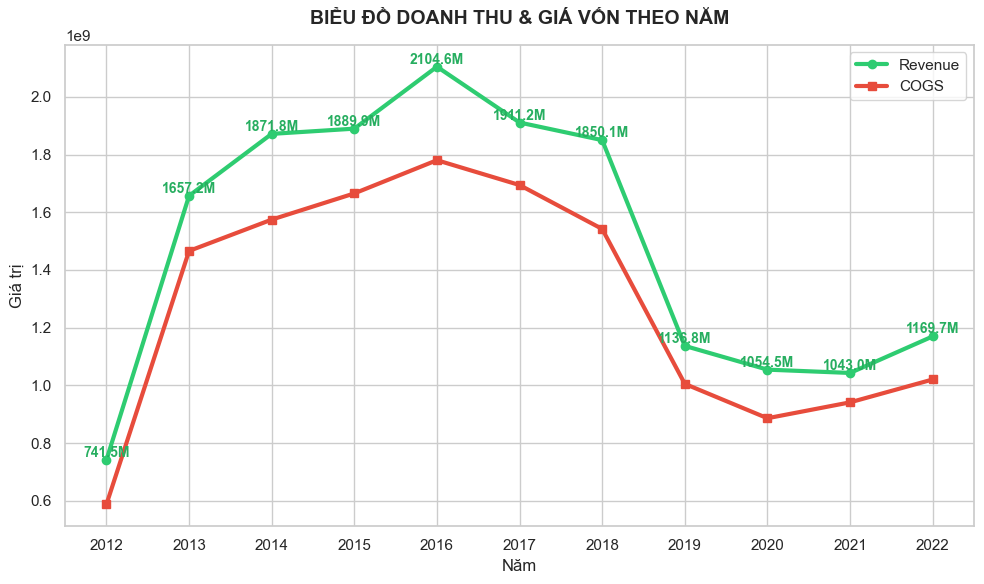

In [35]:
df_sales['Date'] = pd.to_datetime(df_sales['Date'])

# Tạo cột Year và tính tổng theo năm
df_yearly = df_sales.groupby(df_sales['Date'].dt.year).agg({
    'Revenue': 'sum',
    'COGS': 'sum'
}).reset_index()

# 2. Vẽ biểu đồ
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# Vẽ đường Revenue & COGS theo Năm
plt.plot(df_yearly['Date'], df_yearly['Revenue'], marker='o', label='Revenue', color='#2ecc71', linewidth=3)
plt.plot(df_yearly['Date'], df_yearly['COGS'], marker='s', label='COGS', color='#e74c3c', linewidth=3)

# 3. Trang trí
plt.title('BIỂU ĐỒ DOANH THU & GIÁ VỐN THEO NĂM', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Giá trị', fontsize=12)

# Hiển thị số liệu (Data Labels) theo đơn vị tỷ (hoặc triệu tùy ông)
for i in range(len(df_yearly)):
    plt.text(df_yearly['Date'][i], df_yearly['Revenue'][i], f"{df_yearly['Revenue'][i]/1e6:.1f}M", 
             va='bottom', ha='center', fontsize=10, color='#27ae60', fontweight='bold')

# Fix trục X chỉ hiển thị số năm nguyên (2012, 2013...)
plt.xticks(df_yearly['Date'].astype(int)) 

plt.legend()
plt.tight_layout()
plt.show()

TOP 8 SEGMENTS CÓ TỶ SUẤT LỢI NHUẬN GỘP CAO NHẤT


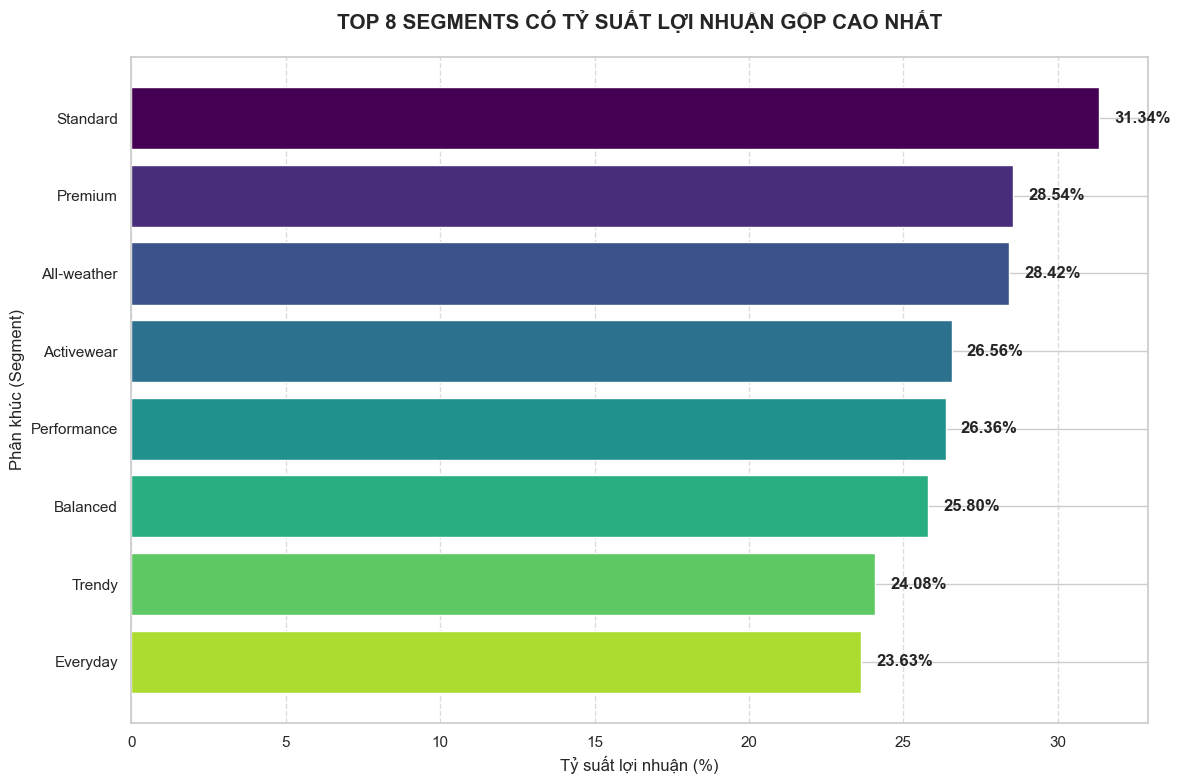

In [38]:

print("TOP 8 SEGMENTS CÓ TỶ SUẤT LỢI NHUẬN GỘP CAO NHẤT")
# 1. Tính Tỷ suất lợi nhuận gộp cho từng sản phẩm
# Công thức: (Price - COGS) / Price
df_products['gross_margin'] = (df_products['price'] - df_products['cogs']) / df_products['price']

# 2. Gom nhóm theo Segment và tính trung bình (Mean)
# Sau đó sắp xếp giảm dần và lấy 8 thằng đầu bảng
df_top8_segment = df_products.groupby('segment')['gross_margin'].mean().sort_values(ascending=False).head(8).reset_index()

# Chuyển về % cho dễ đọc
df_top8_segment['margin_pct'] = df_top8_segment['gross_margin'] * 100

# 3. Vẽ biểu đồ cột ngang (Horizontal Bar Chart)
plt.figure(figsize=(12, 8))
colors = plt.cm.viridis(range(0, 256, 32)) # Tạo bảng màu cho đẹp

bars = plt.barh(df_top8_segment['segment'], df_top8_segment['margin_pct'], color=colors)

# 4. Trang trí biểu đồ
plt.title('TOP 8 SEGMENTS CÓ TỶ SUẤT LỢI NHUẬN GỘP CAO NHẤT', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tỷ suất lợi nhuận (%)', fontsize=12)
plt.ylabel('Phân khúc (Segment)', fontsize=12)
plt.gca().invert_yaxis()  # Đảo ngược trục Y để thằng cao nhất nằm trên cùng
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Ghi số liệu % trực tiếp lên đầu cột
for bar in bars:
    width = bar.get_width()
    plt.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
             f'{width:.2f}%', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

--- TOP 8 SẢN PHẨM CÓ TỔNG LỢI NHUẬN CAO NHẤT ---
| product_name      |      profit |
|:------------------|------------:|
| SaigonFlex UM-43  | 1.14765e+08 |
| UrbanVN UE-05     | 6.96343e+07 |
| SaigonFlex UC-69  | 4.77537e+07 |
| SaigonFlex UM-48  | 4.22822e+07 |
| SaigonFlex UM-38  | 3.86465e+07 |
| HanoiStreet RP-21 | 3.71478e+07 |
| SaigonFlex UM-04  | 3.16209e+07 |
| SaigonFlex UM-80  | 2.85342e+07 |


C:\Users\ACER\AppData\Local\Temp\ipykernel_4296\3413986935.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


C:\Users\ACER\AppData\Local\Temp\ipykernel_4296\3413986935.py:36: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.

C:\Users\ACER\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128202 (\N{BAR CHART}) missing from font(s) Arial.



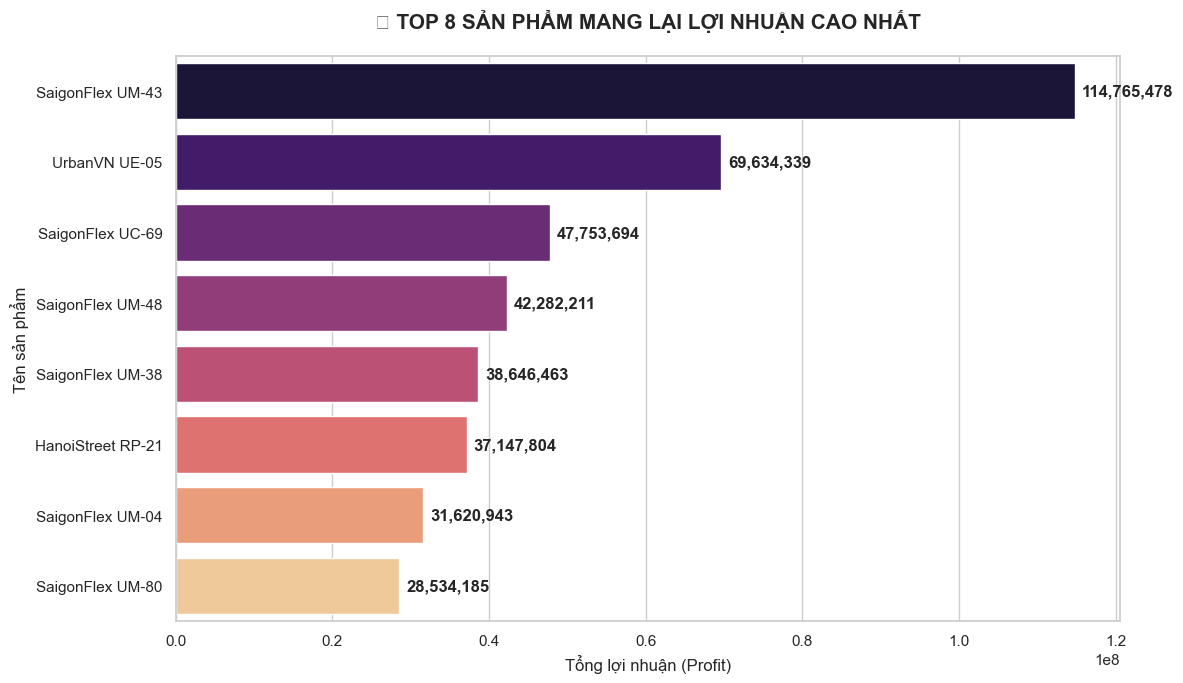

In [47]:
df_step1 = df_order_items.merge(df_orders[['order_id', 'order_date']], on='order_id', how='left')

# 2. Nối tiếp với df_products để lấy [product_name, price, cogs]
# Lưu ý: 'price' ở đây là giá niêm yết, 'unit_price' ở items là giá bán thực tế
df_step2 = df_step1.merge(df_products[['product_id', 'product_name', 'cogs']], on='product_id', how='left')

# 3. Tính lợi nhuận (Profit) cho từng dòng
# Công thức: Lợi nhuận = (Doanh thu thuần) - (Tổng giá vốn)
# Doanh thu thuần = (Số lượng * Giá bán) - Chiết khấu
# Tổng giá vốn = Số lượng * cogs
df_step2['revenue'] = (df_step2['quantity'] * df_step2['unit_price']) - df_step2['discount_amount']
df_step2['total_cogs'] = df_step2['quantity'] * df_step2['cogs']
df_step2['profit'] = df_step2['revenue'] - df_step2['total_cogs']

# 4. Aggregate: Tính tổng lợi nhuận theo từng sản phẩm và lấy Top 8
df_top8_profit = df_step2.groupby('product_name')['profit'].sum().sort_values(ascending=False).head(8).reset_index()

print("--- TOP 8 SẢN PHẨM CÓ TỔNG LỢI NHUẬN CAO NHẤT ---")
print(df_top8_profit.to_markdown(index=False))

# 5. Vẽ biểu đồ cột ngang cho chuyên nghiệp
plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")

chart = sns.barplot(data=df_top8_profit, x='profit', y='product_name', palette='magma')

# Trang trí
plt.title('📊 TOP 8 SẢN PHẨM MANG LẠI LỢI NHUẬN CAO NHẤT', fontsize=15, fontweight='bold', pad=20)
plt.xlabel('Tổng lợi nhuận (Profit)', fontsize=12)
plt.ylabel('Tên sản phẩm', fontsize=12)

# Thêm nhãn số tiền lên đầu cột (đơn vị triệu cho gọn nếu số lớn)
for container in chart.containers:
    chart.bar_label(container, fmt='{:,.0f}', padding=5, fontweight='bold')

plt.tight_layout()
plt.show()

C:\Users\ACER\AppData\Local\Temp\ipykernel_4296\3357026131.py:37: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.

C:\Users\ACER\AppData\Roaming\Python\Python313\site-packages\IPython\core\pylabtools.py:170: UserWarning:

Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) Arial.



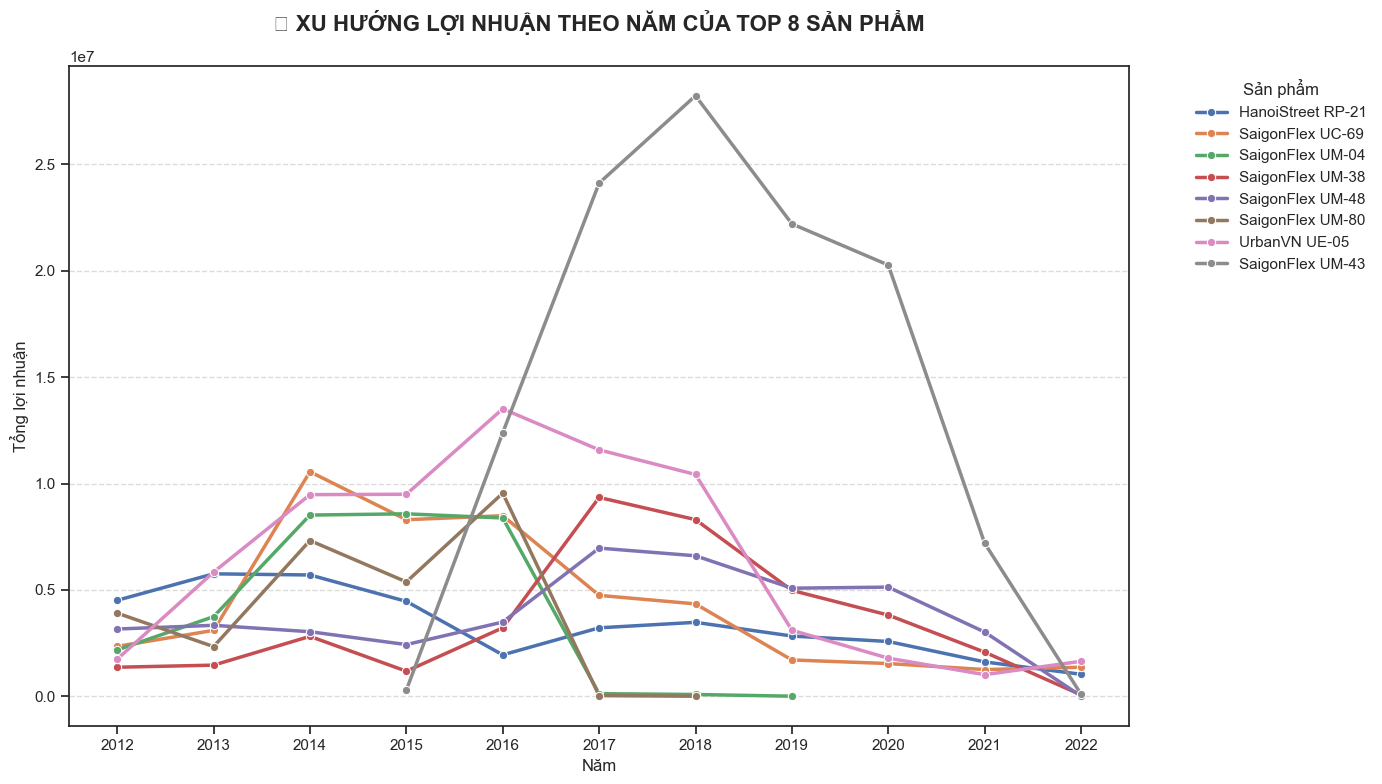

In [48]:
# 1. Lấy danh sách tên Top 8 sản phẩm từ bước trước
top_8_names = df_top8_profit['product_name'].tolist()

# 2. Lọc df_step2 chỉ lấy dữ liệu của 8 sản phẩm này
df_top8_timeseries = df_step2[df_step2['product_name'].isin(top_8_names)].copy()

# 3. Trích xuất năm từ order_date
df_top8_timeseries['year'] = pd.to_datetime(df_top8_timeseries['order_date']).dt.year

# 4. Gom nhóm theo Năm và Tên sản phẩm để tính tổng lợi nhuận
df_yearly_profit = df_top8_timeseries.groupby(['year', 'product_name'])['profit'].sum().reset_index()

# 5. Vẽ biểu đồ đường (Timeseries)
plt.figure(figsize=(14, 8))
sns.set_theme(style="ticks")

# Dùng lineplot với 'hue' là tên sản phẩm để phân tách các đường
plot = sns.lineplot(
    data=df_yearly_profit, 
    x='year', 
    y='profit', 
    hue='product_name', 
    marker='o', 
    linewidth=2.5
)

# Trang trí biểu đồ cho "đẹp" và chuyên nghiệp
plt.title('📈 XU HƯỚNG LỢI NHUẬN THEO NĂM CỦA TOP 8 SẢN PHẨM', fontsize=16, fontweight='bold', pad=25)
plt.xlabel('Năm', fontsize=12)
plt.ylabel('Tổng lợi nhuận', fontsize=12)
plt.xticks(df_yearly_profit['year'].unique()) # Hiển thị rõ từng năm trên trục X

# Đưa chú thích (legend) ra ngoài để không đè lên đường vẽ
plt.legend(title='Sản phẩm', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=False)

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()